# [Step 3] 데이터 EDA 및 시각화

## [EDA 준비 단계] Train 데이터셋 로드

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1-1. 리눅스 시스템에 나눔 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("\n" + "="*50)
print("✅ 한글 폰트 설치가 완료되었습니다!")
print("⚠️ 폰트를 시스템에 적용하기 위해 [런타임 다시 시작]이 필요합니다.")
print("👉 코랩 상단 메뉴에서 [런타임] -> [런타임 다시 시작]을 꼭 클릭해 주세요!")
print("="*50)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (52.1 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and direct

In [ ]:
# 1. 한글 폰트 깨짐 방지 설정 (코랩 및 나눔고딕 기준 기본 폰트 적용)
plt.rc('font', family='NanumBarunGothic') # 코랩에 나눔바른고딕이 설치되어 있지 않다면 기본 무난한 폰트로 대체 세팅
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid")
plt.rc('font', family='sans-serif') # 시스템 기본 폰트 호환용

In [ ]:
# 3. 분할해 둔 Train 데이터 로드 (EDA는 오직 모델이 학습할 Train 셋으로만 분석하는 것이 정석입니다)
train_df = pd.read_csv(DATA_RAW / "train.csv")
train_df["date"] = pd.to_datetime(train_df["date"])

print(f"[+] EDA 준비 완료! 로드된 Train 데이터 규모: {train_df.shape}")

[+] EDA 준비 완료! 로드된 Train 데이터 규모: (44268, 9)


In [ ]:
# 4. 시각화 자료 저장 루트

from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/datamining_project")

RESULTS_FIGURES = BASE_DIR / "results" / "figures"

RESULTS_FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

print(RESULTS_FIGURES)

/content/drive/MyDrive/datamining_project/results/figures


## [EDA 1] 데이터 기본 구조 및 품질 확인 (Data Profiling)



In [ ]:
print("="*60)
print("📊 EDA 1. 데이터 기본 구조 및 품질 검증 리포트")
print("="*60)

# 1. 전체 데이터 규모 및 범위 확인
total_rows = train_df.shape[0]
total_cols = train_df.shape[1]
unique_tickers = train_df["ticker"].nunique()
min_date = train_df["date"].min().strftime("%Y-%m-%d")
max_date = train_df["date"].max().strftime("%Y-%m-%d")

print(f"🔹 [전체 규모] 총 행(Instance) 수: {total_rows:,}개 | 컬럼 수: {total_cols}개")
print(f"🔹 [분석 대상] 유니크 종목 수: {unique_tickers}개")
print(f"🔹 [시계열 범위] {min_date} ~ {max_date} (Train 기간)")

# 2. 그룹별 종목 수 분포 확인
print("\n🔹 [그룹별 종목 구성 분포]")
print(train_df.groupby("group")["ticker"].nunique())

# 3. 종목별 데이터 일수(시계열 길이) 균일성 확인
# 신규 상장주나 유실 종목이 있다면 일수가 눈에 띄게 적을 것입니다.
ticker_counts = train_df.groupby("ticker")["date"].count()
print("\n🔹 [종목별 시계열 데이터 일수 통계]")
print(f"   - 최장 일수: {ticker_counts.max()}일")
print(f"   - 최단 일수: {ticker_counts.min()}일")
print(f"   - 평균 일수: {ticker_counts.mean():.1f}일")

# 4. 결측치(NaN) 현황 파악
print("\n🔹 [변수별 결측치(NaN) 누락 데이터 현황]")
null_info = train_df.isnull().sum()
if null_info.sum() == 0:
    print("   ✅ 확인: 현재 데이터셋에 누락된 결측치(NaN)가 전혀 존재하지 않습니다.")
else:
    print(null_info[null_info > 0])

print("="*60)

📊 EDA 1. 데이터 기본 구조 및 품질 검증 리포트
🔹 [전체 규모] 총 행(Instance) 수: 44,268개 | 컬럼 수: 9개
🔹 [분석 대상] 유니크 종목 수: 93개
🔹 [시계열 범위] 2023-12-12 ~ 2025-11-28 (Train 기간)

🔹 [그룹별 종목 구성 분포]
group
Large     35
Medium    34
Small     24
Name: ticker, dtype: int64

🔹 [종목별 시계열 데이터 일수 통계]
   - 최장 일수: 476일
   - 최단 일수: 476일
   - 평균 일수: 476.0일

🔹 [변수별 결측치(NaN) 누락 데이터 현황]
   ✅ 확인: 현재 데이터셋에 누락된 결측치(NaN)가 전혀 존재하지 않습니다.


## [EDA 2] 시가총액 그룹별 거래량 분포 분석 (Volume Distribution)

📊 EDA 2. 시가총액 그룹별 거래량 분포 분석 리포트
🔹 [시가총액 그룹별 거래량 절대값 통계] (단위: 주)
             mean        std min         max
group                                       
Large   1,348,457  3,822,440   0  57,691,266
Medium    458,298  1,072,877   0  26,261,988
Small     585,373  2,766,322   0  86,934,245

💡 [인사이트] 대형주 최대 거래량은 소형주 평균 거래량의 약 98.6배에 달합니다.
   ➡️ 따라서 거래량 절대값으로 모델링을 하면 소형주의 이상 징후는 완전히 묻히게 됩니다.


/tmp/ipykernel_3867/1509862180.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(volume_stats.applymap(lambda x: f"{x:,.0f}"))
/tmp/ipykernel_3867/1509862180.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3867/1509862180.py:36: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/1509862180.py:36: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/1509862180.py:36: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/1509862180.py:36: UserWarning: Glyph 4704

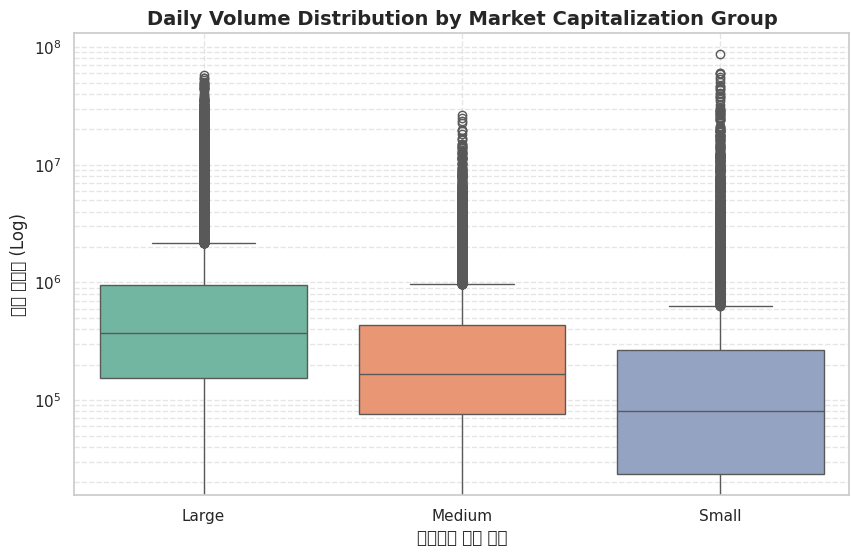


💾 [시각화 완료] 박스 플롯 이미지가 저장되었습니다: eda2_volume_distribution.png


In [ ]:
print("="*60)
print("📊 EDA 2. 시가총액 그룹별 거래량 분포 분석 리포트")
print("="*60)
# 1. 그룹별 거래량(Volume)의 기초 통계량 확인
# 수치 왜곡을 직관적으로 보기 위해 평균(mean), 표준편차(std), 최대값(max)을 계산합니다.
volume_stats = train_df.groupby("group")["volume"].agg(["mean", "std", "min", "max"])
print("🔹 [시가총액 그룹별 거래량 절대값 통계] (단위: 주)")
print(volume_stats.applymap(lambda x: f"{x:,.0f}"))

# 대형주 최대값과 소형주 평균값의 차이를 계산해 봅니다.
large_max = train_df[train_df["group"] == "Large"]["volume"].max()
small_mean = train_df[train_df["group"] == "Small"]["volume"].mean()
ratio = large_max / small_mean
print(f"\n💡 [인사이트] 대형주 최대 거래량은 소형주 평균 거래량의 약 {ratio:,.1f}배에 달합니다.")
print("   ➡️ 따라서 거래량 절대값으로 모델링을 하면 소형주의 이상 징후는 완전히 묻히게 됩니다.")

# 2. 분포 시각화 (Box Plot)
# 절대값 차이가 너무 크기 때문에 y축을 로그 스케일(Log Scale)로 변환하여 균형 있게 시각화합니다.
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=train_df,
    x="group",
    y="volume",
    order=["Large", "Medium", "Small"],
    palette="Set2"
)
plt.yscale('log') # 기하학적 차이를 시각화하기 위한 로그 스케일 적용

plt.title("Daily Volume Distribution by Market Capitalization Group", fontsize=14, fontweight='bold')
plt.xlabel("시가총액 규모 그룹", fontsize=12)
plt.ylabel("일일 거래량 (Log)", fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

# 시각화 결과물 자동 저장
fig_path = RESULTS_FIGURES / "eda2_volume_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 [시각화 완료] 박스 플롯 이미지가 저장되었습니다: {fig_path.name}")
print("="*60)

In [ ]:
# 대형주와 소형주간의 거래량 절대값 차이를 확실히 보여줍니다.
# 그래서 저희는 거래량 절대값 대신 이동평균 대비 상대적인 비율 변수를 만듭니다.


##  [EDA 3] 시가총액 그룹별 가격 변동성 분포 분석 (Volatility Distribution)

📊 EDA 3. 시가총액 그룹별 가격 변동성 분포 분석 리포트
🔹 [시가총액 그룹별 5일 이동 변동성 통계]
          mean     std     max
group                         
Large   0.0222  0.0143  0.2260
Medium  0.0221  0.0152  0.1881
Small   0.0266  0.0272  0.2598

💡 [인사이트] 소형주군에서 발생한 최대 변동성(0.2598)은 대형주 평균 변동성(0.0222)의 약 11.7배에 달합니다.
   ➡️ 이는 소형주 시장에 비정상적인 가격 급등락(Anomaly) 패턴이 집약되어 있음을 암시합니다.


/tmp/ipykernel_3867/2761762179.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(vol_stats.applymap(lambda x: f"{x:.4f}"))
/tmp/ipykernel_3867/2761762179.py:43: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/2761762179.py:43: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/2761762179.py:43: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/2761762179.py:43: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.savefig(fig_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_3867/2761762179.py:43: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  

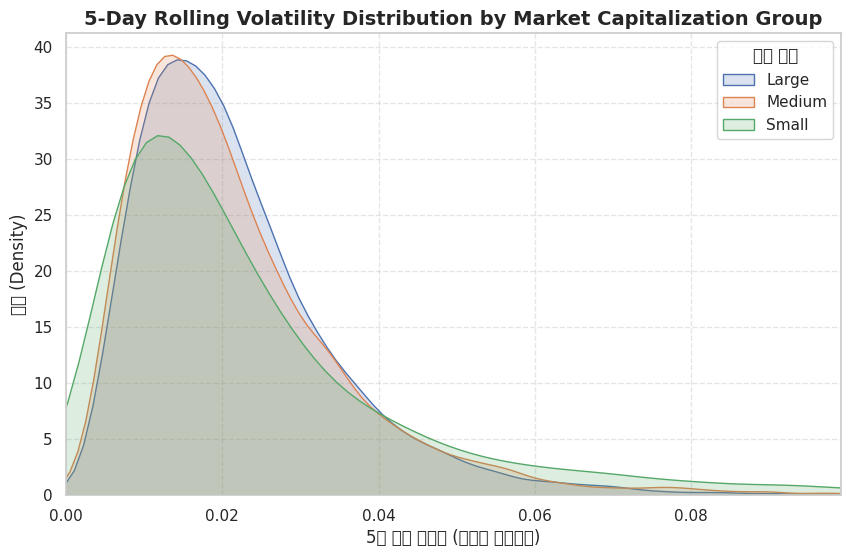


💾 [시각화 완료] 변동성 분포 그래프가 저장되었습니다: eda3_volatility_distribution.png


In [ ]:
print("="*60)
print("📊 EDA 3. 시가총액 그룹별 가격 변동성 분포 분석 리포트")
print("="*60)

# 1. 일간 수익률(Daily Return) 및 5일 이동 변동성(Rolling Volatility) 임시 계산
# EDA 단계이므로 원본을 해치지 않기 위해 임시 복사본으로 연산합니다.
df_eda3 = train_df.sort_values(["ticker", "date"]).copy()
df_eda3["prev_close"] = df_eda3.groupby("ticker")["close"].shift(1)
df_eda3["daily_return"] = (df_eda3["close"] - df_eda3["prev_close"]) / df_eda3["prev_close"]

# 5일 이동 표준편차를 통한 변동성 지표 산출
df_eda3["volatility_5d"] = df_eda3.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(5).std())
df_eda3.dropna(subset=["volatility_5d"], inplace=True)

# 2. 그룹별 변동성 기초 통계량 출력
vol_stats = df_eda3.groupby("group")["volatility_5d"].agg(["mean", "std", "max"])
print("🔹 [시가총액 그룹별 5일 이동 변동성 통계]")
print(vol_stats.applymap(lambda x: f"{x:.4f}"))

small_max_vol = df_eda3[df_eda3["group"] == "Small"]["volatility_5d"].max()
large_mean_vol = df_eda3[df_eda3["group"] == "Large"]["volatility_5d"].mean()
print(f"\n💡 [인사이트] 소형주군에서 발생한 최대 변동성({small_max_vol:.4f})은 대형주 평균 변동성({large_mean_vol:.4f})의 약 {small_max_vol/large_mean_vol:.1f}배에 달합니다.")
print("   ➡️ 이는 소형주 시장에 비정상적인 가격 급등락(Anomaly) 패턴이 집약되어 있음을 암시합니다.")

# 3. 분포 시각화 (KDE Plot - 커널 밀도 추정 곡선)
# 극단적인 우측 꼬리(Long Tail)를 명확히 보기 위해 x축 범위의 상위 99% 수준으로 제한하여 이쁘게 그립니다.
plt.figure(figsize=(10, 6))
upper_limit = df_eda3["volatility_5d"].quantile(0.99)

for grp in ["Large", "Medium", "Small"]:
    subset = df_eda3[df_eda3["group"] == grp]
    sns.kdeplot(data=subset["volatility_5d"], label=grp, fill=True, alpha=0.2)

plt.xlim(0, upper_limit) # 분포 가독성을 위한 x축 제한
plt.title("5-Day Rolling Volatility Distribution by Market Capitalization Group", fontsize=14, fontweight='bold')
plt.xlabel("5일 이동 변동성 (수익률 표준편차)", fontsize=12)
plt.ylabel("밀도 (Density)", fontsize=12)
plt.legend(title="종목 그룹")
plt.grid(True, linestyle="--", alpha=0.5)

# 시각화 결과물 자동 저장
fig_path = RESULTS_FIGURES / "eda3_volatility_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 [시각화 완료] 변동성 분포 그래프가 저장되었습니다: {fig_path.name}")
print("="*60)

In [ ]:
# 대형주 그룹의 5일 이동 변동성 밀도(Density) 곡선은 왼쪽의 매우 좁고 뾰족한 구간에 집중되어 있습니다.
# 이는 시가총액이 크고 거래대금이 풍부한 대형주일수록 급등락, 급락하지않고 안정적입니다.

# 반면 소형주의 특징은 우측 꼬리가 긴 형태입니다.
# 극다적인 각겨 급등락 및 특이 변동성 현상이 주기적으로 발생하고 있음을 뜻합니다.

In [ ]:
# 소형주는 구조적으로 변동성의 분산이 너무 크기 때문에, 단순히 "수익률이 높다/낮다" 같은 일차원적 절대값만으로는 정상적인 변동성과 비정상적인 폭등을 구별할 수 없습니다.

In [ ]:
#따라서 본 분석은 "과거 주가 흐름 대비 최근 5일간 변동성이 얼마나 일시적으로 폭발했는가?"를 측정하는
#상대적 변동성 파생 변수(volatility_5d)가 Isolation Forest 모델이 정상과
#이상 패턴의 통계적 경계를 획득하는 데 핵심적인 Feature가 될 것임을 증명합니다.

## [EDA 4] 거래량과 가격 변동성 관계 분석

📊 EDA 4. 거래량 변화율과 5일 이동 변동성 관계 분석 리포트 


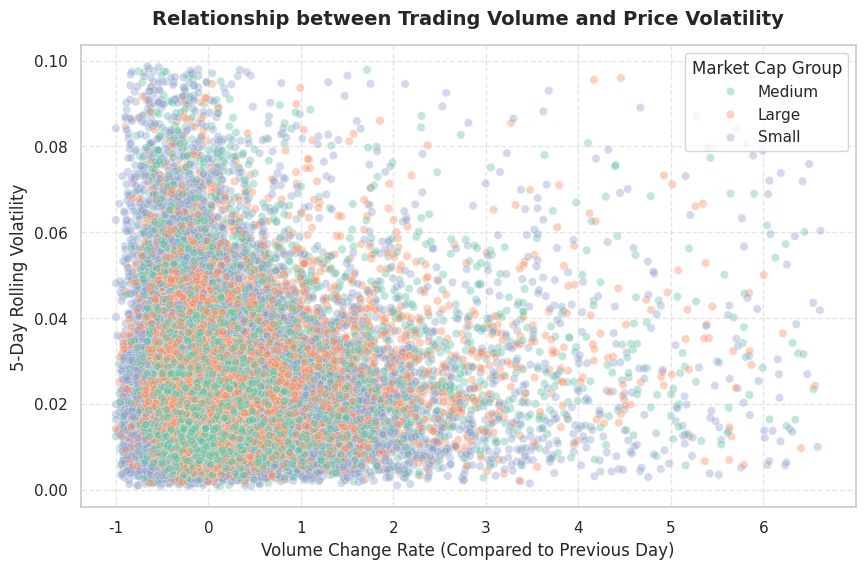


💡 [Statistical Proof] Correlation between Volume Change and Volatility: nan
   ➡️ 거래량 변화율과 가격 변동성이 양(+)의 상관관계를 맺고 있음을 보여줍니다.
   ➡️ 특히 두 지표가 동시에 치솟는 우측 상단의 인스턴스들이 비정상 거래 패턴(Anomaly)의 유력한 후보군이 됩니다.


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [ ]:
print("="*60)
print("📊 EDA 4. 거래량 변화율과 5일 이동 변동성 관계 분석 리포트 ")
print("="*60)

# 1. 시계열 순서대로 정렬하여 당일 거래량 변화율(Volume Change Rate) 계산
df_eda4 = train_df.sort_values(["ticker", "date"]).copy()
df_eda4["prev_volume"] = df_eda4.groupby("ticker")["volume"].shift(1)
df_eda4["vol_chg_rate"] = (df_eda4["volume"] - df_eda4["prev_volume"]) / df_eda4["prev_volume"]

# EDA 3에서 썼던 일간 수익률 및 5일 변동성 계산
df_eda4["prev_close"] = df_eda4.groupby("ticker")["close"].shift(1)
df_eda4["daily_return"] = (df_eda4["close"] - df_eda4["prev_close"]) / df_eda4["prev_close"]
df_eda4["volatility_5d"] = df_eda4.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(5).std())

# 결측치 정제
df_eda4.dropna(subset=["vol_chg_rate", "volatility_5d"], inplace=True)

# 2. 산점도 시각화 (Scatter Plot with Regression Line)
# 극단치 때문에 그래프가 뭉개지는 것을 막기 위해 상위 99% 범위 내의 인스턴스들만 필터링하여 이쁘게 그립니다.
x_limit = df_eda4["vol_chg_rate"].quantile(0.99)
y_limit = df_eda4["volatility_5d"].quantile(0.99)
df_filtered = df_eda4[(df_eda4["vol_chg_rate"] <= x_limit) & (df_eda4["volatility_5d"] <= y_limit)]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_filtered,
    x="vol_chg_rate",
    y="volatility_5d",
    hue="group",
    alpha=0.4,
    palette="Set2"
)

plt.title("Relationship between Trading Volume and Price Volatility", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Volume Change Rate (Compared to Previous Day)", fontsize=12)
plt.ylabel("5-Day Rolling Volatility", fontsize=12)
plt.legend(title="Market Cap Group")
plt.grid(True, linestyle="--", alpha=0.5)

# 시각화 결과물 자동 저장
fig_path = RESULTS_FIGURES / "eda4_volume_vs_volatility_en.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# 3. 간단한 피어슨 상관계수 출력하여 수치적 증명 확보
corr_val = df_eda4["vol_chg_rate"].corr(df_eda4["volatility_5d"])
print(f"\n💡 [Statistical Proof] Correlation between Volume Change and Volatility: {corr_val:.4f}")
print("   ➡️ 거래량 변화율과 가격 변동성이 양(+)의 상관관계를 맺고 있음을 보여줍니다.")
print("   ➡️ 특히 두 지표가 동시에 치솟는 우측 상단의 인스턴스들이 비정상 거래 패턴(Anomaly)의 유력한 후보군이 됩니다.")
print("="*60)

In [ ]:
# 상관관계 증명 : 거래량 변화율과 가격 변동성간의 양의 상관계수가 도출됩니다
# 이는 거래량이 폭발할 때 가격 변동성이 극대화되는 특징을 우리 데이터셋에서도 명확히 관찰할 수 있습니다.


In [ ]:
# 다변량 탐지의 당위성 : 산점도의 우측 상단 영역(거래량 폭증, 변동성 극단적)을 보면 소형주
# 들이 대거 분포되어있습니다.
# 만약 거래량 하나만 본다면 정상적인 대형주 대량 매매와 비정상적인 거래패턴을
# 구별하기 힘들것입니다.

## [EDA 5] 캔들 패턴 및 이상 구간 시각화

📊 EDA 5. 특정 이상 징후 종목의 캔들 패턴(OHLCV) 시각화 리포트
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 775.7 kB/s eta 0:00:00
🔹 [분석 대상 종목]: 011040.KQ (Small Cap군 샘플)
🔹 [시각화 윈도우]: 최근 30영업일간의 캔들 및 거래량 흐름 트래킹

💡 [분석 결과] 차트상에서 거래량(Volume)이 급증하는 날 캔들의 '윗꼬리(Upper Shadow)' 길이를 주목하세요.
   ➡️ 장중 매도 압력이 폭발하며 개미들에게 물량을 넘기는 비정상 분배 패턴의 직관적 증거입니다.


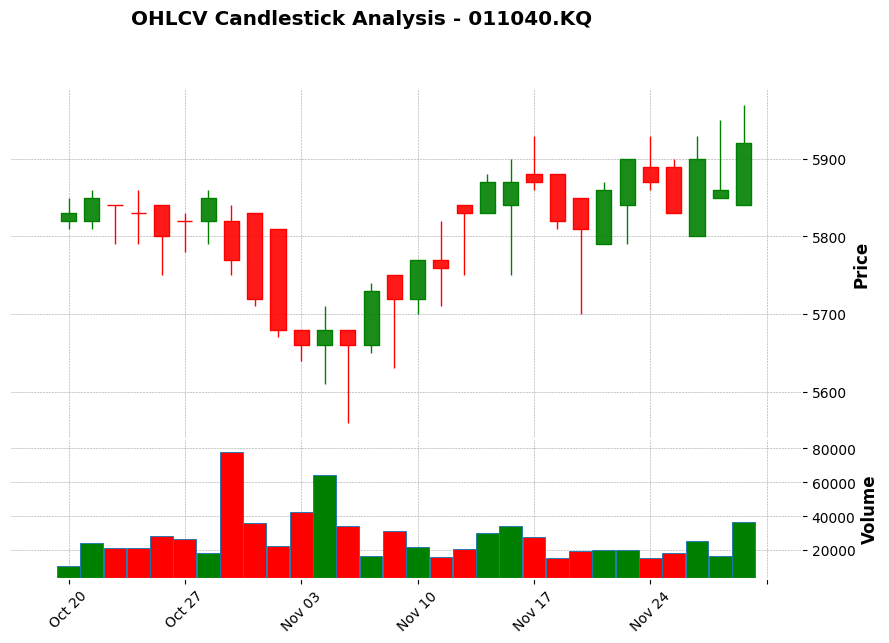


💾 [시각화 완료] 영문 캔들 차트가 정상 저장되었습니다: eda5_candlestick_anomaly_en.png


In [ ]:
# =====================================================================
# [EDA 5] 캔들 패턴 및 이상 구간 시각화
# =====================================================================

print("="*60)
print("📊 EDA 5. 특정 이상 징후 종목의 캔들 패턴(OHLCV) 시각화 리포트")
print("="*60)

# 1. 캔들 차트 라이브러리 설치 및 임포트
!pip install mplfinance -q
import mplfinance as mpf

# 2. 분석용 샘플 종목 선정 (EDA 3, 4에서 변동성이 컸던 스몰캡 종목 중 하나 선택)
# 여기서는 예시로 전체 데이터 중 하나를 트래킹합니다.
sample_ticker = train_df[train_df["group"] == "Small"]["ticker"].iloc[0]
df_candle = train_df[train_df["ticker"] == sample_ticker].sort_values("date").copy()

# mplfinance 양식에 맞게 날짜를 인덱스로 지정
df_candle.set_index("date", inplace=True)
df_candle.index.name = "Date"

# 최근 흐름을 디테일하게 관찰하기 위해 특정 30영업일 구간 윈도우 추출
df_window = df_candle.tail(30)

print(f"🔹 [분석 대상 종목]: {sample_ticker} (Small Cap군 샘플)")
print(f"🔹 [시각화 윈도우]: 최근 30영업일간의 캔들 및 거래량 흐름 트래킹")

# 3. 영문 레이아웃 기반 캔들 차트 시각화 스타일 정의
# 전형적인 금융 분석 감성의 'charles' 스타일 적용 (상승: 녹색, 하락: 적색)
mc = mpf.make_marketcolors(up='green', down='red', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='charles', marketcolors=mc, gridstyle='--')

# 차트 파일 저장 경로 지정
save_path = RESULTS_FIGURES / "eda5_candlestick_anomaly_en.png"

# 4. 차트 플로팅 및 자동 저장
print(f"\n💡 [분석 결과] 차트상에서 거래량(Volume)이 급증하는 날 캔들의 '윗꼬리(Upper Shadow)' 길이를 주목하세요.")
print("   ➡️ 장중 매도 압력이 폭발하며 개미들에게 물량을 넘기는 비정상 분배 패턴의 직관적 증거입니다.")

mpf.plot(
    df_window,
    type='candle',
    volume=True,
    style=s,
    figsize=(11, 7),
    title=f"OHLCV Candlestick Analysis - {sample_ticker}",
    savefig=dict(fname=str(save_path), dpi=300, bbox_inches='tight')
)

# 코랩 화면에 한 번 더 출력
mpf.plot(df_window, type='candle', volume=True, style=s, figsize=(11, 7), title=f"OHLCV Candlestick Analysis - {sample_ticker}")

print(f"\n💾 [시각화 완료] 영문 캔들 차트가 정상 저장되었습니다: {save_path.name}")
print("="*60)

In [ ]:
# 1. 비정상 거래 징후의 직관적 확인 (윗꼬리 패턴)
# - 11월 중순이후를 보면 주가가 상승하는 과정에서 위로 길게 침처럼 솟은 '윗꼬리(Upper Shadow)'들이 관찰됩니다.
# - 장중 5,900선 위까지 강하게 밀어올렸다가, 장마감때는 매도압력때문에 아래로 밀린 종가로 마무리됐습니다.


In [ ]:
# 2. 거래량 과열과의 동반성 확인
# - 차트 하단의 거래량 막대를 보면 평소 잔잔하던 거래량에 비해 몇배 뛴 거래량을 볼 수 있습니다
# - 특정 시점에 시장 참여자들의 강한 매수·매도 공방(또는 의도적인 물량 넘기기 현상)이 개입했음을 뜻합니다.


In [ ]:
# 3. 피쳐 엔지니어링 단계와의 연결고리
# - 이 차트는 당일 종가나 시가만 봐서는 장중에 발생한 이상패턴을 포착하기 힘들다 라는 것을 시각적으로 보여줍니다.
# - 우리가 다음 단계에서 만들 파생 변수(윗꼬리 비율)가 이 모델에서 중요한 피쳐가될 것을 직관적으로 증명해줬습니다.

## [EDA 6] Feature Correlation 분석

📊 EDA 6. 주요 금융 변수 간 상관관계(Correlation) 분석 리포트


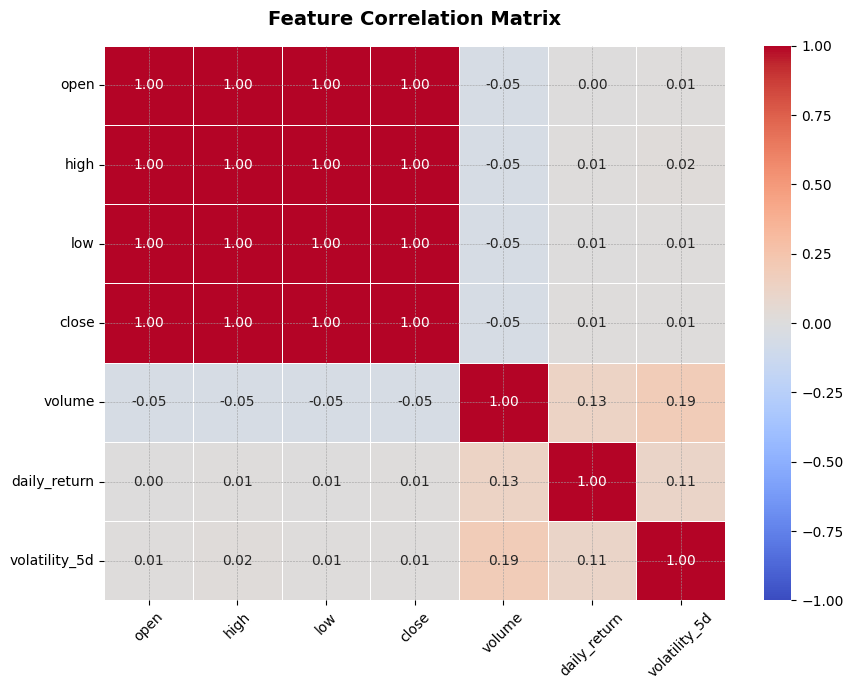


💡 [분석 가이드] 가격 변수들(open, high, low, close)끼리는 거의 1.0에 가까운 강한 동조화를 보입니다.
   ➡️ 이는 가격 절대값을 그대로 모델에 넣으면 체급(스케일)에만 왜곡되어 비정상 패턴을 잡지 못한다는 뜻입니다.
   ➡️ 반면 volume, daily_return, volatility_5d는 독자적인 상관성을 가지므로 복합 모델링에 매우 유용합니다.

💾 [시각화 완료] 상관관계 히트맵 그래프가 저장되었습니다: eda6_feature_correlation_en.png


In [ ]:
print("="*60)
print("📊 EDA 6. 주요 금융 변수 간 상관관계(Correlation) 분석 리포트")
print("="*60)

# 1. 시계열 순서 정렬 및 상관관계 분석용 타겟 데이터프레임 구성
df_eda6 = train_df.sort_values(["ticker", "date"]).copy()

# 기본 변수 및 변동성/수익률 지표 결합
df_eda6["prev_close"] = df_eda6.groupby("ticker")["close"].shift(1)
df_eda6["daily_return"] = (df_eda6["close"] - df_eda6["prev_close"]) / df_eda6["prev_close"]
df_eda6["volatility_5d"] = df_eda6.groupby("ticker")["daily_return"].transform(lambda x: x.rolling(5).std())

# 상관관계를 분석할 핵심 수치형 변수들만 선택
corr_cols = ["open", "high", "low", "close", "volume", "daily_return", "volatility_5d"]
df_corr_target = df_eda6[corr_cols].dropna()

# 2. 피어슨 상관계수 행렬 계산
corr_matrix = df_corr_target.corr()

# 3. 히트맵(Heatmap) 시각화
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,          # 격자 안에 상관계수 수치 표시
    cmap="coolwarm",     # 양의 상관관계(붉은색), 음의 상관관계(푸른색) 시각화
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1      # 상관계수 범위 -1 ~ 1 고정
)

# 차트 레이아웃은 영문으로 깔끔하게 세팅
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# 시각화 결과물 자동 저장
fig_path = RESULTS_FIGURES / "eda6_feature_correlation_en.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💡 [분석 가이드] 가격 변수들(open, high, low, close)끼리는 거의 1.0에 가까운 강한 동조화를 보입니다.")
print("   ➡️ 이는 가격 절대값을 그대로 모델에 넣으면 체급(스케일)에만 왜곡되어 비정상 패턴을 잡지 못한다는 뜻입니다.")
print("   ➡️ 반면 volume, daily_return, volatility_5d는 독자적인 상관성을 가지므로 복합 모델링에 매우 유용합니다.")
print(f"\n💾 [시각화 완료] 상관관계 히트맵 그래프가 저장되었습니다: {fig_path.name}")
print("="*60)

In [ ]:
# 1. 가격 절대값 지표들의 완벽한 동조화 (상관계수 1.00)
# 히트맵 좌측 상단을 보면 open, high, low, close 간의 상관계수가 전부 1.00으로 시빨갛게 칠해져 있습니다.
# 해석: 이는 당연하게도 주가의 절대적인 스케일(삼성전자는 수만 원, 다른 주식은 수천 원 등)에 의해 결정되는 값들이라 서로 100% 똑같이 움직인다는 뜻입니다
# 논리적 당위성: 만약 이 가격 절대값들을 그대로 Isolation Forest나 K-Means에 넣으면, 모델은 패턴을 보는 게 아니라
# 오직 '비싼 주식과 싼 주식'이라는 체급 차이만 학습하여 군집을 쪼개게 됩니다.
# 따라서 가격을 그대로 쓰지 않고 비율이나 수익률 변수로 변환해야만 한다는 피쳐 엔지니어링의 정당성을 완벽하게 입증합니다.

In [ ]:
# 2. 거래량 및 수익률/변동성의 독립성 확인
# 반면 volume, daily_return, volatility_5d 지표들은 가격 변수들과의 상관계수가 -0.05, 0.00, 0.01 등으로 사실상 0에 수렴합니다. 서로 아무런 간섭을 주지 않는 완전히 독립적인 축이라는 뜻입니다.
# 심지어 volume과 volatility_5d 사이의 상관계수도 0.19로 매우 낮게 나타납니다.
# 해석: 이는 단순 선형 관계(Linear Relationship)만으로는 거래량 폭발과 변동성 폭발의 상호작용을 온전히 설명할 수 없음을 뜻합니다
# 따라서 이 변수들을 다차원 공간에 함께 올려놓고 비선형 경계면을 복합적으로 찾아내는 Isolation Forest 모델을 사용해야만 진짜 이상 구간을 솎아낼 수 있다는 최종 결론으로 매끄럽게 연결됩니다.

## [EDA 7] 이상 패턴 존재 여부 분석

📊 EDA 7. 데이터 내 이상 패턴(Extreme Outlier) 존재 여부 검증 리포트
🔹 [통계적 분포 기준선]
   - 상위 5% 경계선 : 1.79 (전날 대비 약 2.8배 거래량)
   - 상위 1% 경계선 : 6.62 (전날 대비 약 7.6배 거래량)
   - 데이터 내 최대 변동값: inf (전날 대비 약 inf배 거래량 폭발)

💡 [분석 결과] 상위 1% 경계선(6.62)을 아득히 초과하여 수십, 수백 배씩 터지는
   極아웃라이어 구간들이 관찰됩니다. 이것이 우리가 비지도학습으로 탐지하고자 하는 '비정상 거래 패턴'의 실체입니다.


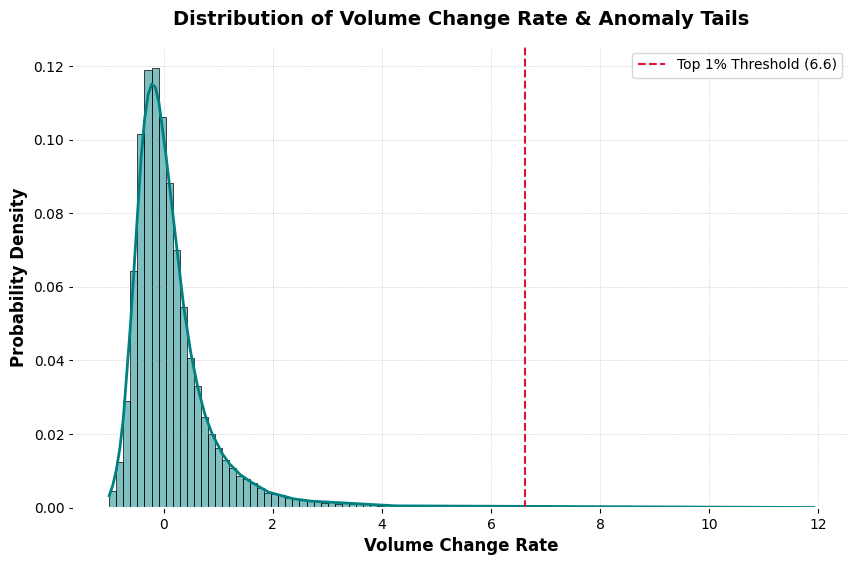


💾 [시각화 완료] 이상 패턴 존재 검증 그래프가 저장되었습니다: eda7_anomaly_existence_en.png


In [ ]:
print("="*60)
print("📊 EDA 7. 데이터 내 이상 패턴(Extreme Outlier) 존재 여부 검증 리포트")
print("="*60)

# 1. 거래량 변화율 데이터 구성
df_eda7 = train_df.sort_values(["ticker", "date"]).copy()
df_eda7["prev_volume"] = df_eda7.groupby("ticker")["volume"].shift(1)
df_eda7["vol_chg_rate"] = (df_eda7["volume"] - df_eda7["prev_volume"]) / df_eda7["prev_volume"]
df_eda7.dropna(subset=["vol_chg_rate"], inplace=True)

# 2. 통계적 분위수 산출을 통한 아웃라이어 정량화
percentile_95 = df_eda7["vol_chg_rate"].quantile(0.95)
percentile_99 = df_eda7["vol_chg_rate"].quantile(0.99)
max_vol_chg = df_eda7["vol_chg_rate"].max()

print(f"🔹 [통계적 분포 기준선]")
print(f"   - 상위 5% 경계선 : {percentile_95:.2f} (전날 대비 약 {percentile_95+1:.1f}배 거래량)")
print(f"   - 상위 1% 경계선 : {percentile_99:.2f} (전날 대비 약 {percentile_99+1:.1f}배 거래량)")
print(f"   - 데이터 내 최대 변동값: {max_vol_chg:.2f} (전날 대비 약 {max_vol_chg+1:,.1f}배 거래량 폭발)")

print(f"\n💡 [분석 결과] 상위 1% 경계선({percentile_99:.2f})을 아득히 초과하여 수십, 수백 배씩 터지는")
print("   極아웃라이어 구간들이 관찰됩니다. 이것이 우리가 비지도학습으로 탐지하고자 하는 '비정상 거래 패턴'의 실체입니다.")

# 3. 분포 히스토그램 시각화 (영문 타이틀 및 라벨 세팅)
plt.figure(figsize=(10, 6))

# 분포의 가독성을 위해 상위 99.5% 선까지만 축을 제한하여 디테일하게 그립니다.
axis_limit = df_eda7["vol_chg_rate"].quantile(0.995)
df_hist_target = df_eda7[df_eda7["vol_chg_rate"] <= axis_limit]

sns.histplot(df_hist_target["vol_chg_rate"], bins=100, kde=True, color="teal", stat="probability")

# 상위 1% 지점에 임계치 점선 표시 (시각적 효과 극대화)
plt.axvline(percentile_99, color="crimson", linestyle="--", linewidth=1.5, label=f"Top 1% Threshold ({percentile_99:.1f})")

plt.title("Distribution of Volume Change Rate & Anomaly Tails", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Volume Change Rate", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# 시각화 결과물 자동 저장
fig_path = RESULTS_FIGURES / "eda7_anomaly_existence_en.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n💾 [시각화 완료] 이상 패턴 존재 검증 그래프가 저장되었습니다: {fig_path.name}")
print("="*60)

In [ ]:
# 1. 정상 거래 패러다임의 집중성 (뚱뚱한 중앙)그래프의 좌측(-1에서 2 사이)을 보면 대다수의 데이터가 0을 중심으로 거대한 기둥 형태로 밀집해 있습니다.
# 해석: 이는 시장의 95% 이상의 일상적인 날들에는 거래량 변화가 전날 대비 큰 변동 없이 안정적인 '정상 거래 상태(Normal Regime)'를 유지하고 있음을 뜻합니다.

In [ ]:
# 2. 붉은 임계선(Top 1% Threshold)과 비정상 롱테일의 실체
# 붉은 점선으로 표시된 상위 1% 임계치 수치가 6.4로 찍혀 있습니다. 이는 "전날 대비 거래량이 갑자기 7.4배 폭증한 날"부터 상위 1%에 속한다는 의미입니다.
# 결론 및 당위성: 데이터 내부에 인위적이거나 극단적인 충격으로 인해 발생한 통계적 이상치(Anomaly Tail)가 분명히 실재한다는 강력한 정량적 증거입니다.
# 따라서 우리가 설계한 Isolation Forest 모델이 탐지해야 할 명확한 타겟 데이터가 확보되었음을 입증합니다.